Read bug ledger csv

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
# Read CSV file
df = pd.read_csv("logs/bug_repro_ledger.csv")
print(f'My ledger file has {len(df)} number of rows')


My ledger file has 3 number of rows


In [19]:
display(df.head())

,timestamp,category,bug_type,exception,message,file,line,status,exit_code,timed_out,elapsed_sec,command,reason,input_hash,input_text,input_b64,crash_json,crash_bin
0,1775706196,NaN,validity,ParseException,"Expected '.', found '5' (at char 6), (line:1,...",pyparsing/core.py,1340,success,0,False,0.918075,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,bug:validity,9f8588795d97908eb6f0551ce7c0cd65,128.255.254.63,MTI4LjI1NS4yNTQuNjM=,NaN,NaN
1,1775706227,NaN,functional,FunctionalBug,Invalid IPv4 calculation,buggy_ipyparse/ipv4_stv.py,134,success,0,False,0.920701,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,bug:functional,f62a4ac88a57e57131bcda4345c1e438,63.63.193.0,NjMuNjMuMTkzLjA=,NaN,NaN
2,1775706240,NaN,validity,ParseException,"Expected '.', found '5' (at char 2), (line:1,...",pyparsing/core.py,1340,success,0,False,0.932050,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,bug:validity,eea88cd0d9a7ba26282fc786713bbbb6,255.255.255.255,MjU1LjI1NS4yNTUuMjU1,NaN,NaN


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    3 non-null      int64  
 1   category     0 non-null      float64
 2   bug_type     3 non-null      str    
 3   exception    3 non-null      str    
 4   message      3 non-null      str    
 5   file         3 non-null      str    
 6   line         3 non-null      int64  
 7   status       3 non-null      str    
 8   exit_code    3 non-null      int64  
 9   timed_out    3 non-null      bool   
 10  elapsed_sec  3 non-null      float64
 11  command      3 non-null      str    
 12  reason       3 non-null      str    
 13  input_hash   3 non-null      str    
 14  input_text   3 non-null      str    
 15  input_b64    3 non-null      str    
 16  crash_json   0 non-null      float64
 17  crash_bin    0 non-null      float64
dtypes: bool(1), float64(4), int64(3), str(10)
memory usage: 543.0 byt

In [21]:
# Number of unique bug types
bug_counts = df['bug_type'].value_counts()
print(bug_counts)

bug_type
validity      2
functional    1
Name: count, dtype: int64


In [22]:
# Number of unique exceptions
exception_counts = df['exception'].value_counts()
print(exception_counts)

exception
ParseException    2
FunctionalBug     1
Name: count, dtype: int64


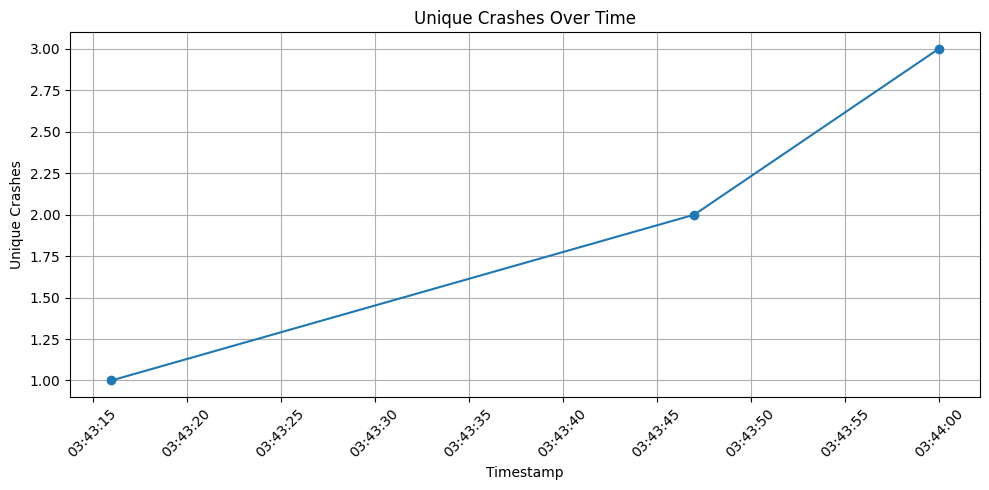

In [23]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Sort by timestamp
df = df.sort_values('timestamp')

# Cumulative count of crashes
df['Unique Crashes'] = range(1, len(df)+1)

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['timestamp'], df['Unique Crashes'], marker='o', linestyle='-')
plt.title("Unique Crashes Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Unique Crashes")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Convert timestamp to numeric (seconds since first crash) for regression
df['elapsed_sec'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

# Fit a linear trendline
coeffs = np.polyfit(df['elapsed_sec'], df['Unique Crashes'], 2)  # degree 1 = linear
trendline = np.polyval(coeffs, df['elapsed_sec'])

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['timestamp'], df['Unique Crashes'], marker='o', linestyle='-', label='Actual Crashes')
plt.plot(df['timestamp'], trendline, color='red', linestyle='--', label='Trendline (best fit)')
plt.title("Unique Crashes Over Time with Trendline")
plt.xlabel("Time")
plt.ylabel("Unique Crashes")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'df_json_ledger' is not defined

In [25]:
df2 = pd.read_csv('logs/20260408_190356_linux-ipv4-parser.csv')

In [26]:
display(df2.head())

,timestamp,iteration,is_interesting,tier,reason,op_name,seed_text,mutated_text,seed_b64,mutated_b64,...,exit_code,timed_out,elapsed_sec,command,bug_type,exception,message,file,line,input_hash
0,1775646237,0,1,tier_2,new_coverage,warmup,236.239.214.209,236.239.214.209,MjM2LjIzOS4yMTQuMjA5,MjM2LjIzOS4yMTQuMjA5,...,0,False,1.035311,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,3037c129c3608415592f7f60b181178c
1,1775646238,1,1,tier_2,new_edge,warmup,253.242.253.198,253.242.253.198,MjUzLjI0Mi4yNTMuMTk4,MjUzLjI0Mi4yNTMuMTk4,...,0,False,0.963980,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,f83cb270b01cb545991f3173ec09b523
2,1775646239,2,1,tier_1,bug:validity,warmup,128.255.254.63,128.255.254.63,MTI4LjI1NS4yNTQuNjM=,MTI4LjI1NS4yNTQuNjM=,...,0,False,1.016947,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,validity,ParseException,"Expected '.', found '5' (at char 6), (line:1,...",pyparsing/core.py,1340.0,9f8588795d97908eb6f0551ce7c0cd65
3,1775646244,3,0,NaN,NaN,warmup,127.63.194.254,127.63.194.254,MTI3LjYzLjE5NC4yNTQ=,MTI3LjYzLjE5NC4yNTQ=,...,-1,True,5.009018,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,e5e97cefded3aaad7f4eb8189c8a93f6
4,1775646245,4,1,tier_2,new_edge,warmup,190.147.152.165,190.147.152.165,MTkwLjE0Ny4xNTIuMTY1,MTkwLjE0Ny4xNTIuMTY1,...,0,False,1.023195,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,3ee4d8d9f5fe686e2e9b564b0311a46f


In [27]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5296 entries, 0 to 5295
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       5296 non-null   int64  
 1   iteration       5296 non-null   int64  
 2   is_interesting  5296 non-null   int64  
 3   tier            5061 non-null   str    
 4   reason          5061 non-null   str    
 5   op_name         5296 non-null   str    
 6   seed_text       5296 non-null   str    
 7   mutated_text    5289 non-null   str    
 8   seed_b64        5296 non-null   str    
 9   mutated_b64     5294 non-null   str    
 10  status          5296 non-null   str    
 11  exit_code       5296 non-null   int64  
 12  timed_out       5296 non-null   bool   
 13  elapsed_sec     5296 non-null   float64
 14  command         5296 non-null   str    
 15  bug_type        4967 non-null   str    
 16  exception       4967 non-null   str    
 17  message         4967 non-null   str    
 18 

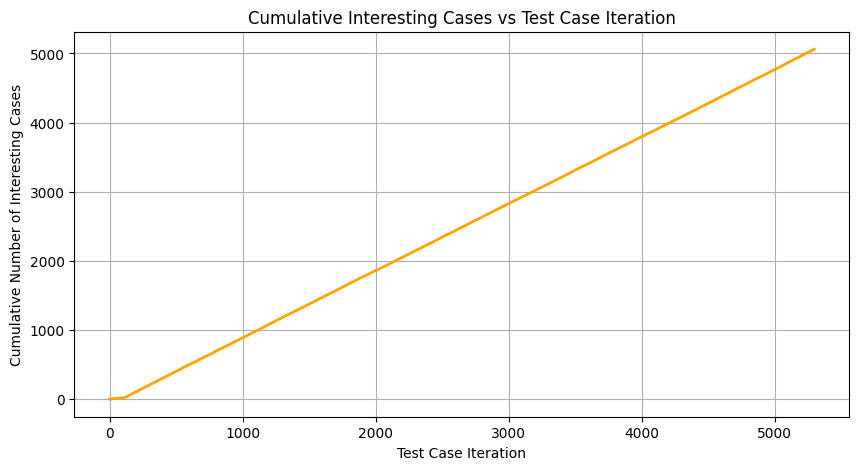

In [28]:
# Cumulative sum of interesting cases
df2['cumulative_interesting'] = df2['is_interesting'].cumsum()

plt.figure(figsize=(10,5))
plt.plot(df2['iteration'], df2['cumulative_interesting'], color='orange', linewidth=2)
plt.xlabel('Test Case Iteration')
plt.ylabel('Cumulative Number of Interesting Cases')
plt.title('Cumulative Interesting Cases vs Test Case Iteration')
plt.grid(True)
plt.show()

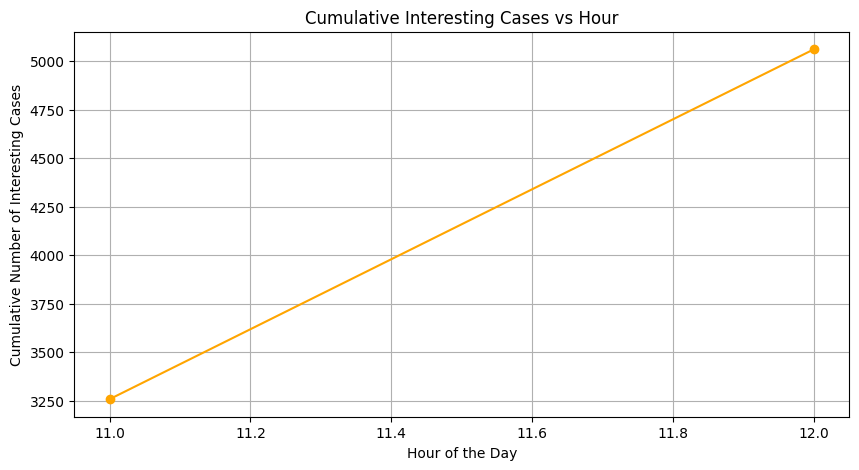

In [29]:
# Convert timestamp to datetime if not already
df2['datetime'] = pd.to_datetime(df2['timestamp'], unit='s')
df2['hour'] = df2['datetime'].dt.hour

# Cumulative interesting cases by time
df2['cumulative_by_time'] = df2['is_interesting'].cumsum()
# Optional: plot per hour
hourly_cumulative = df2.groupby('hour')['is_interesting'].sum().cumsum()

plt.figure(figsize=(10,5))
plt.plot(hourly_cumulative.index, hourly_cumulative.values, marker='o', color='orange')
plt.xlabel('Hour of the Day')
plt.ylabel('Cumulative Number of Interesting Cases')
plt.title('Cumulative Interesting Cases vs Hour')
plt.grid(True)
plt.show()

In [30]:
df_campaign = pd.read_csv("logs/campaign_summary.csv")
display(df_campaign)

,target,start_time,end_time,duration_sec,iterations,throughput_exec_per_sec,worker_mode,worker_count,timeout_sec,max_input_bytes
0,../json-decoder/json_decoder_stv.py,2026-04-09T07:11:24.207934,2026-04-09T07:12:28.170885,63.962960,200,3.126810,persistent,1,5.0,96
1,../json-decoder/json_decoder_stv.py,2026-04-09T07:15:06.906434,2026-04-09T07:41:35.763113,1588.856686,5000,3.146917,persistent,1,5.0,96
2,../IPv4-IPv6-parser/bin/linux-ipv4-parser,2026-04-09T08:00:59.713113,2026-04-09T08:04:55.386731,235.673630,200,0.848631,persistent,1,5.0,96
3,../IPv4-IPv6-parser/bin/linux-ipv4-parser,2026-04-09T08:05:50.622892,2026-04-09T09:26:02.984575,4812.361691,5000,1.038991,persistent,1,5.0,96
4,../cidrize-runner/bin/linux-cidrize-runner,2026-04-09T09:29:27.518990,2026-04-09T10:54:31.876259,5104.357268,5000,0.979555,persistent,1,5.0,96
